In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("student_placement_train.csv")

df.head()

,student_id,age,gender,cgpa,attendance_percentage,backlogs,coding_score,aptitude_score,communication_score,technical_score,...,github_projects,linkedin_score,resume_score,soft_skills_score,leadership_score,extracurricular_score,training_hours,mock_interview_score,preferred_domain,placed
0,STU107218,21,Male,5.75,77.1,0,29.3,39.9,83.0,24.3,...,0,67.8,58.8,87.5,47.7,59.1,43.8,75.8,Data Science,0
1,STU108292,23,Male,7.14,NaN,0,61.7,63.4,55.3,49.0,...,5,53.5,77.8,77.9,71.2,34.5,102.3,70.8,Business Analytics,0
2,STU104608,23,Male,7.68,76.0,0,51.6,59.6,46.3,43.3,...,4,63.6,65.5,55.9,44.3,51.5,96.1,70.8,Business Analytics,0
3,STU105115,24,Male,6.07,75.8,1,24.0,47.5,75.0,65.1,...,3,65.7,59.8,75.6,90.9,54.4,118.5,91.1,Software Development,0
4,STU101860,20,Male,7.97,74.0,1,33.1,47.4,58.1,64.4,...,2,75.3,30.6,73.9,45.0,83.0,59.6,77.0,Business Analytics,0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8000
Columns: 28


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               8000 non-null   object 
 1   age                      8000 non-null   int64  
 2   gender                   8000 non-null   object 
 3   cgpa                     8000 non-null   float64
 4   attendance_percentage    7794 non-null   float64
 5   backlogs                 8000 non-null   int64  
 6   coding_score             7859 non-null   float64
 7   aptitude_score           7881 non-null   float64
 8   communication_score      7851 non-null   float64
 9   technical_score          7869 non-null   float64
 10  projects_count           8000 non-null   int64  
 11  major_projects           8000 non-null   int64  
 12  internships_count        8000 non-null   int64  
 13  internship_months        7762 non-null   float64
 14  certifications_count    

In [5]:
df.describe()

,age,cgpa,attendance_percentage,backlogs,coding_score,aptitude_score,communication_score,technical_score,projects_count,major_projects,...,coding_platform_score,github_projects,linkedin_score,resume_score,soft_skills_score,leadership_score,extracurricular_score,training_hours,mock_interview_score,placed
count,8000.000000,8000.000000,7794.000000,8000.000000,7859.000000,7881.000000,7851.000000,7869.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,7685.000000,7811.000000,7846.000000,8000.000000,8000.000000,7759.000000,7705.000000,8000.00000
mean,21.678250,7.575794,81.914870,0.548000,53.161369,55.982718,57.905757,54.280277,2.602750,0.901875,...,745.479625,2.802750,63.233429,61.485341,71.061088,53.308625,57.803350,54.097049,73.027411,0.20375
std,1.141661,0.846223,8.817563,0.732129,15.742178,14.174136,14.023447,15.527179,1.646673,0.944382,...,236.510996,1.906186,10.990595,11.940017,9.849899,14.302521,16.641169,31.440054,11.222125,0.40281
min,19.000000,5.000000,55.000000,0.000000,15.000000,15.000000,20.000000,15.000000,0.000000,0.000000,...,100.000000,0.000000,26.200000,20.700000,30.000000,15.000000,10.000000,1.400000,27.300000,0.00000
25%,21.000000,7.000000,76.000000,0.000000,42.400000,46.500000,48.350000,43.600000,1.000000,0.000000,...,588.000000,1.000000,55.700000,53.400000,64.400000,43.700000,46.300000,31.300000,65.400000,0.00000
50%,22.000000,7.580000,81.950000,0.000000,52.900000,55.900000,57.800000,54.300000,2.000000,1.000000,...,747.000000,3.000000,63.200000,61.200000,71.000000,53.400000,57.700000,48.300000,73.100000,0.00000
75%,22.000000,8.140000,88.100000,1.000000,63.900000,65.500000,67.300000,64.600000,4.000000,1.000000,...,905.000000,4.000000,70.700000,69.300000,77.800000,63.200000,69.200000,70.700000,80.800000,0.00000
max,26.000000,10.000000,100.000000,4.000000,100.000000,100.000000,100.000000,100.000000,15.000000,7.000000,...,2161.000000,11.000000,100.000000,100.000000,100.000000,100.000000,100.000000,320.000000,100.000000,1.00000


In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'attendance_percentage',
       'backlogs', 'coding_score', 'aptitude_score', 'communication_score',
       'technical_score', 'projects_count', 'major_projects',
       'internships_count', 'internship_months', 'certifications_count',
       'hackathons_participated', 'hackathons_won', 'coding_platform_score',
       'github_projects', 'linkedin_score', 'resume_score',
       'soft_skills_score', 'leadership_score', 'extracurricular_score',
       'training_hours', 'mock_interview_score', 'preferred_domain', 'placed'],
      dtype='object')

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
attendance_percentage,206
coding_score,141
aptitude_score,119
communication_score,149
technical_score,131
internship_months,238
linkedin_score,315
resume_score,189
soft_skills_score,154
training_hours,241


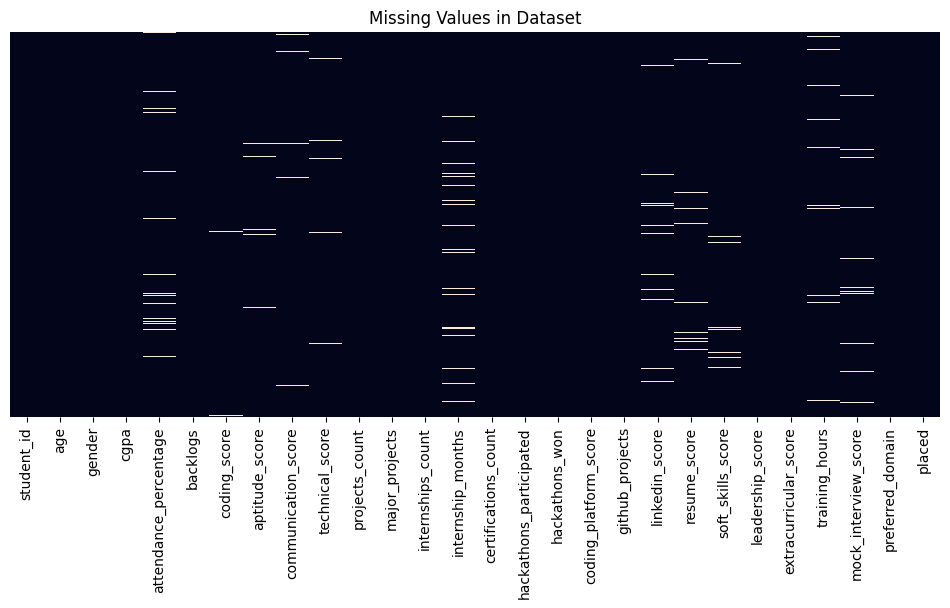

In [8]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Dataset")
plt.show()

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print(df["placed"].value_counts(normalize=True) * 100)

placed
0    79.625
1    20.375
Name: proportion, dtype: float64


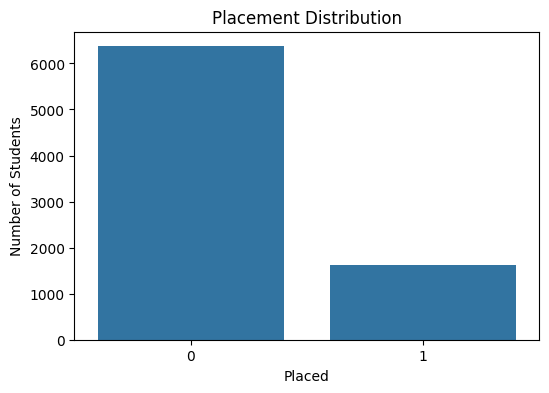

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(x="placed", data=df)

plt.title("Placement Distribution")
plt.xlabel("Placed")
plt.ylabel("Number of Students")
plt.show()

In [12]:
placement_rate = df["placed"].mean() * 100

print(f"Overall Placement Rate: {placement_rate:.2f}%")

Overall Placement Rate: 20.38%


In [13]:
gender_placement = pd.crosstab(
    df["gender"],
    df["placed"],
    normalize="index"
) * 100

gender_placement

placed,0,1
gender,,
Female,78.959811,21.040189
Male,80.061412,19.938588
Other,78.571429,21.428571


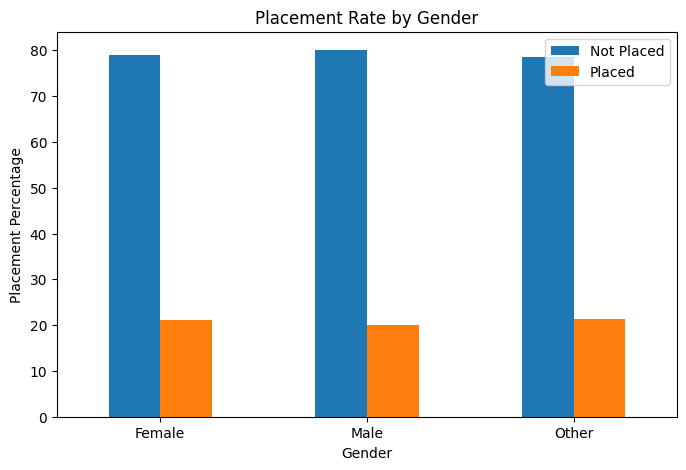

In [14]:
gender_placement.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Placement Rate by Gender")
plt.ylabel("Placement Percentage")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(["Not Placed", "Placed"])

plt.show()

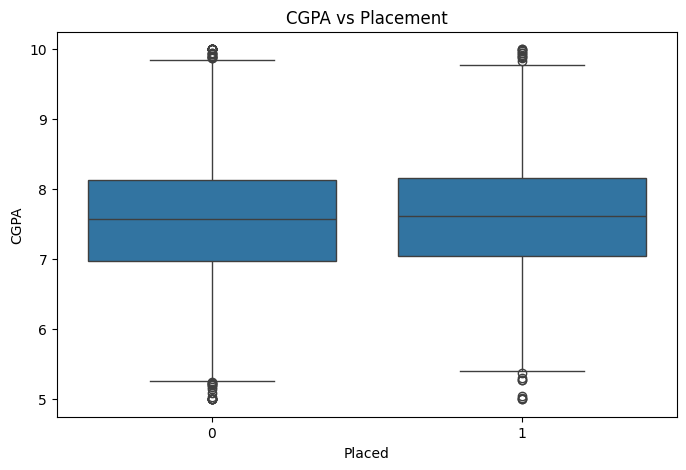

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="placed",
    y="cgpa",
    data=df
)

plt.title("CGPA vs Placement")
plt.xlabel("Placed")
plt.ylabel("CGPA")

plt.show()

In [16]:
df.groupby("placed")["cgpa"].mean()

,cgpa
placed,
0,7.565841
1,7.614687


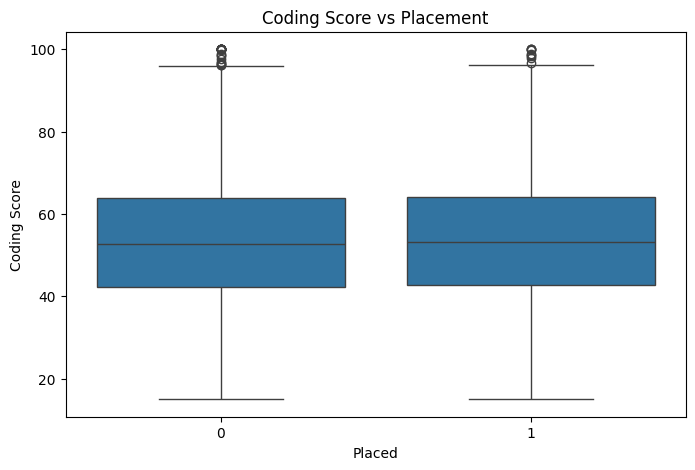

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="placed",
    y="coding_score",
    data=df
)

plt.title("Coding Score vs Placement")
plt.xlabel("Placed")
plt.ylabel("Coding Score")

plt.show()

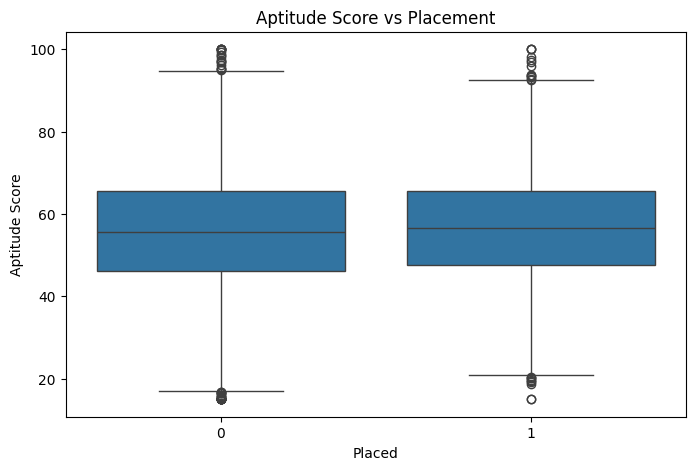

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="placed",
    y="aptitude_score",
    data=df
)

plt.title("Aptitude Score vs Placement")
plt.xlabel("Placed")
plt.ylabel("Aptitude Score")

plt.show()

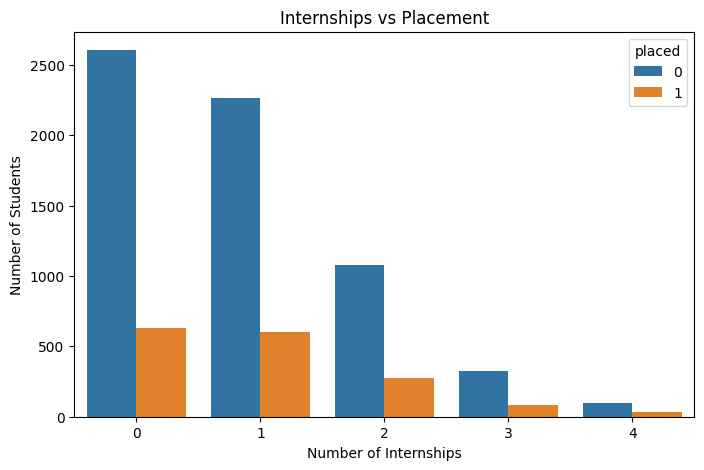

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="internships_count",
    hue="placed",
    data=df
)

plt.title("Internships vs Placement")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Students")

plt.show()

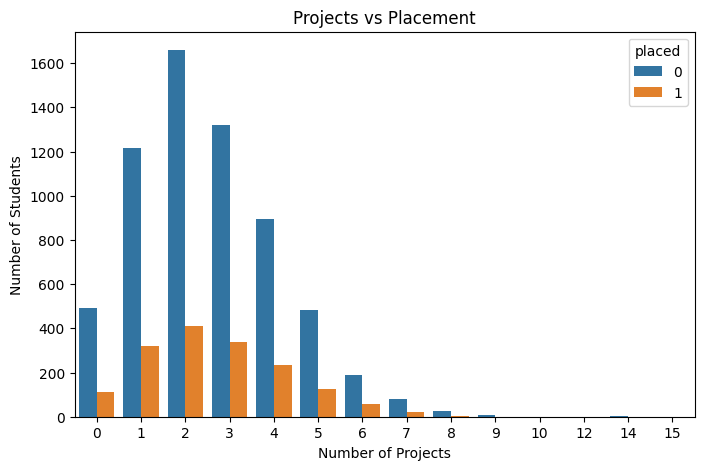

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="projects_count",
    hue="placed",
    data=df
)

plt.title("Projects vs Placement")
plt.xlabel("Number of Projects")
plt.ylabel("Number of Students")

plt.show()

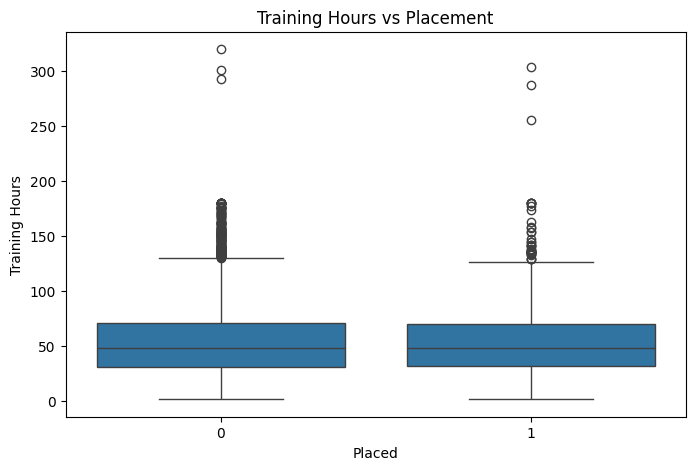

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="placed",
    y="training_hours",
    data=df
)

plt.title("Training Hours vs Placement")
plt.xlabel("Placed")
plt.ylabel("Training Hours")

plt.show()

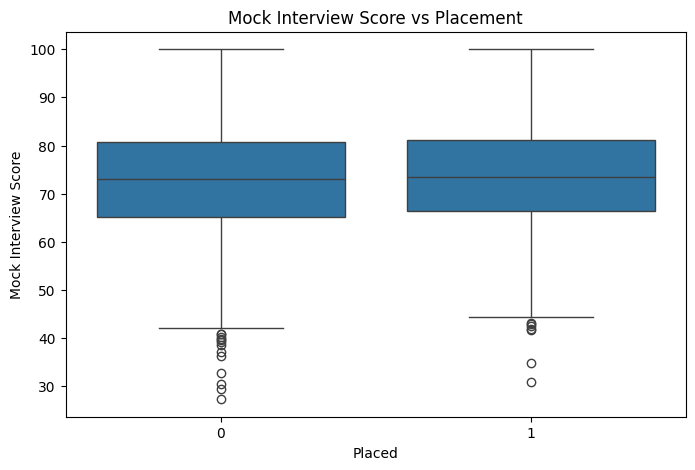

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="placed",
    y="mock_interview_score",
    data=df
)

plt.title("Mock Interview Score vs Placement")
plt.xlabel("Placed")
plt.ylabel("Mock Interview Score")

plt.show()

In [23]:
domain_placement = pd.crosstab(
    df["preferred_domain"],
    df["placed"],
    normalize="index"
) * 100

domain_placement

placed,0,1
preferred_domain,,
AI/ML,78.839349,21.160651
Business Analytics,78.361345,21.638655
Cloud Computing,78.329810,21.670190
Cyber Security,82.067248,17.932752
Data Science,81.124007,18.875993
Software Development,79.235216,20.764784


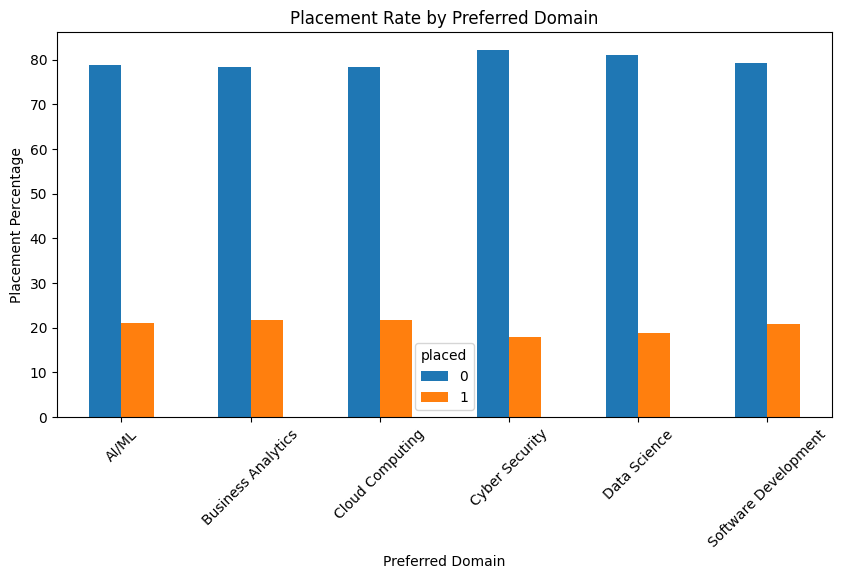

In [24]:
domain_placement.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Placement Rate by Preferred Domain")
plt.ylabel("Placement Percentage")
plt.xlabel("Preferred Domain")
plt.xticks(rotation=45)

plt.show()

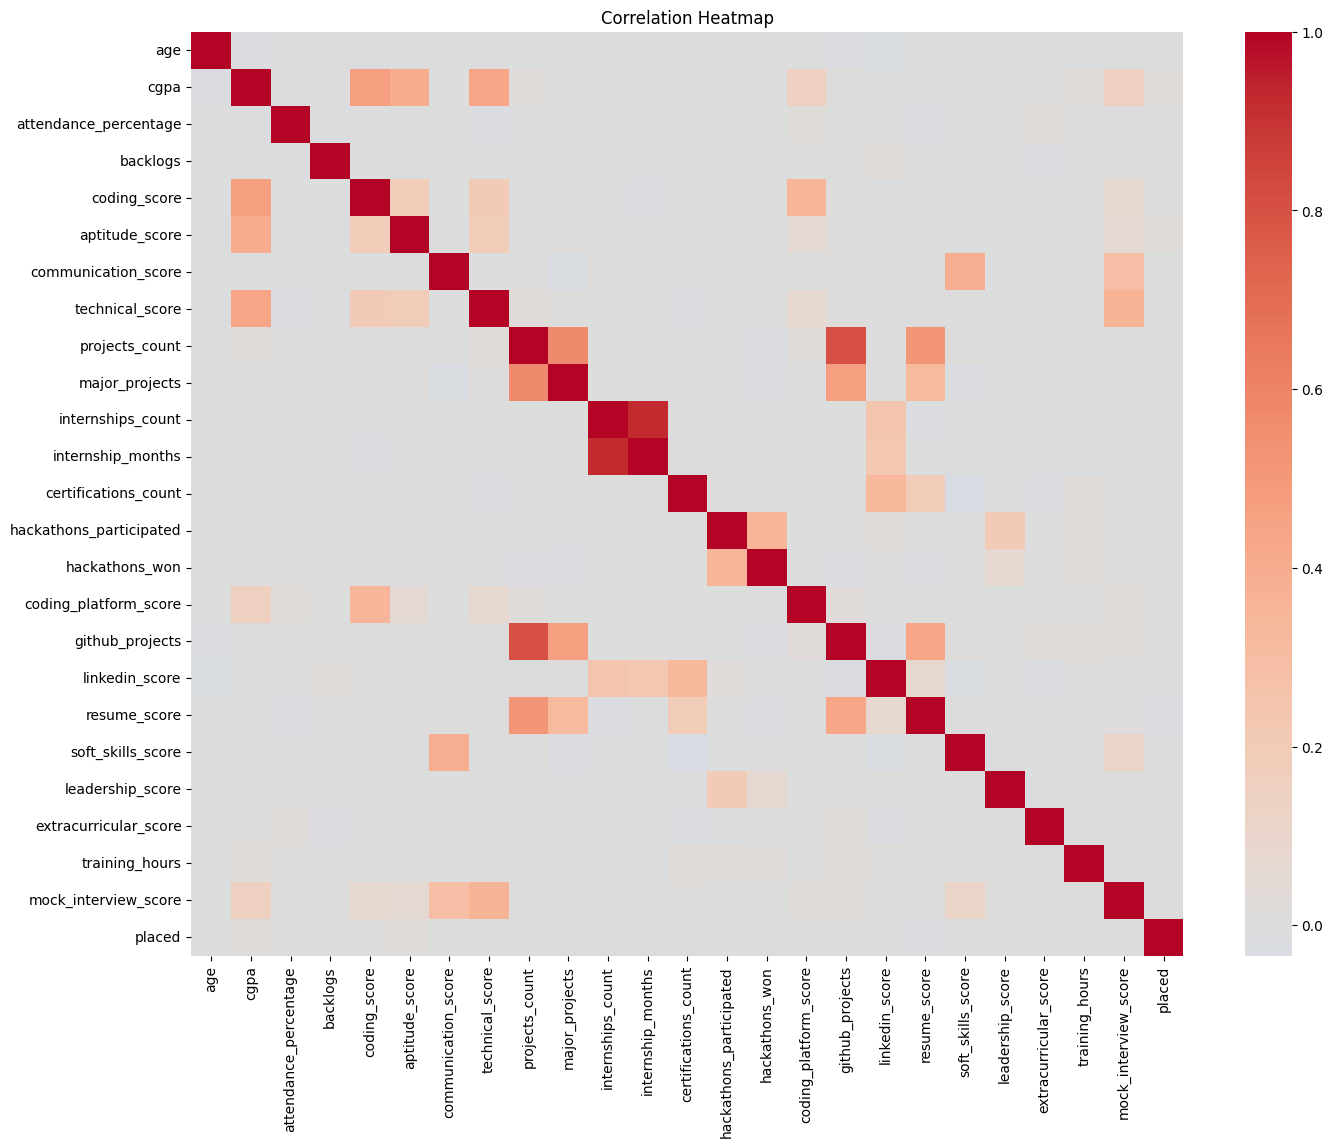

In [25]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
placement_corr = correlation["placed"].sort_values(
    ascending=False
)

placement_corr

,placed
placed,1.000000
cgpa,0.023251
aptitude_score,0.020402
mock_interview_score,0.018506
technical_score,0.018101
internships_count,0.015646
internship_months,0.015088
github_projects,0.013924
coding_platform_score,0.013243
projects_count,0.012537


In [27]:
placement_corr.head(10)

,placed
placed,1.000000
cgpa,0.023251
aptitude_score,0.020402
mock_interview_score,0.018506
technical_score,0.018101
internships_count,0.015646
internship_months,0.015088
github_projects,0.013924
coding_platform_score,0.013243
projects_count,0.012537


In [28]:
placement_corr.tail(10)

,placed
leadership_score,0.003119
attendance_percentage,0.002934
major_projects,0.002611
hackathons_participated,0.001135
training_hours,-0.002465
communication_score,-0.003943
soft_skills_score,-0.006255
backlogs,-0.009428
extracurricular_score,-0.009595
resume_score,-0.014082


In [29]:
df["total_experience"] = (
    df["internship_months"] +
    df["training_hours"] / 10
)

In [30]:
df["achievement_score"] = (
    df["certifications_count"] +
    df["hackathons_won"] +
    df["major_projects"] +
    df["github_projects"]
)

In [31]:
df["overall_skill_score"] = (
    df["coding_score"] +
    df["aptitude_score"] +
    df["communication_score"] +
    df["technical_score"] +
    df["soft_skills_score"]
) / 5

In [32]:
df[
    [
        "total_experience",
        "achievement_score",
        "overall_skill_score"
    ]
].head()

,total_experience,achievement_score,overall_skill_score
0,12.98,5,52.80
1,13.73,7,61.46
2,14.61,8,51.34
3,11.85,5,57.44
4,15.86,4,55.38


In [33]:
X = df.drop(
    columns=["placed", "student_id"]
)

y = df["placed"]

In [34]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (8000, 29)
Target: (8000,)


In [35]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['age', 'cgpa', 'attendance_percentage', 'backlogs', 'coding_score', 'aptitude_score', 'communication_score', 'technical_score', 'projects_count', 'major_projects', 'internships_count', 'internship_months', 'certifications_count', 'hackathons_participated', 'hackathons_won', 'coding_platform_score', 'github_projects', 'linkedin_score', 'resume_score', 'soft_skills_score', 'leadership_score', 'extracurricular_score', 'training_hours', 'mock_interview_score', 'total_experience', 'achievement_score', 'overall_skill_score']

Categorical Features:
['gender', 'preferred_domain']


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6400, 29)
Testing data: (1600, 29)


In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [41]:
from sklearn.impute import SimpleImputer

In [43]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'cgpa', 'attendance_percentage', 'backlogs', 'coding_score',
       'aptitude_score', 'communication_score', 'technical_score',
       'projects_count', 'major_projects', 'internships_count',
       'intern...
       'leadership_score', 'extracurricular_score', 'training_hours',
       'mock_interview_score', 'total_experience', 'achievement_score',
       'overall_skill_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'preferred_domain'], dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [44]:
y_pred_lr = logistic_model.predict(X_test)

In [45]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

precision_lr = precision_score(
    y_test,
    y_pred_lr
)

recall_lr = recall_score(
    y_test,
    y_pred_lr
)

f1_lr = f1_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))

Logistic Regression
-------------------
Accuracy : 0.7963
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


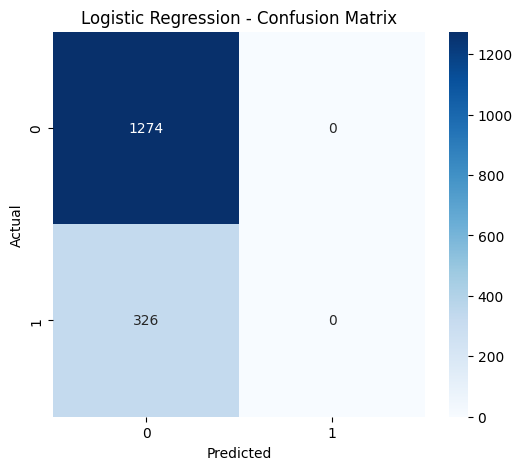

In [46]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1274
           1       0.00      0.00      0.00       326

    accuracy                           0.80      1600
   macro avg       0.40      0.50      0.44      1600
weighted avg       0.63      0.80      0.71      1600



In [48]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                random_state=42
            )
        )
    ]
)

decision_tree.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'cgpa', 'attendance_percentage', 'backlogs', 'coding_score',
       'aptitude_score', 'communication_score', 'technical_score',
       'projects_count', 'major_projects', 'internships_count',
       'intern...
       'mock_interview_score', 'total_experience', 'achievement_score',
       'overall_skill_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'preferred_domain'], dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

In [49]:
y_pred_dt = decision_tree.predict(X_test)

In [50]:
accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

precision_dt = precision_score(
    y_test,
    y_pred_dt
)

recall_dt = recall_score(
    y_test,
    y_pred_dt
)

f1_dt = f1_score(
    y_test,
    y_pred_dt
)

print("Decision Tree")
print("-------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Decision Tree
-------------
Accuracy : 0.79
Precision: 0.1429
Recall   : 0.0061
F1 Score : 0.0118


In [51]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'cgpa', 'attendance_percentage', 'backlogs', 'coding_score',
       'aptitude_score', 'communication_score', 'technical_score',
       'projects_count', 'major_projects', 'internships_count',
       'intern...
       'mock_interview_score', 'total_experience', 'achievement_score',
       'overall_skill_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'preferred_domain'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [52]:
y_pred_rf = random_forest.predict(X_test)

In [53]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest
-------------
Accuracy : 0.7963
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [54]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.79625,0.000000,0.000000,0.000000
1,Decision Tree,0.79000,0.142857,0.006135,0.011765
2,Random Forest,0.79625,0.000000,0.000000,0.000000


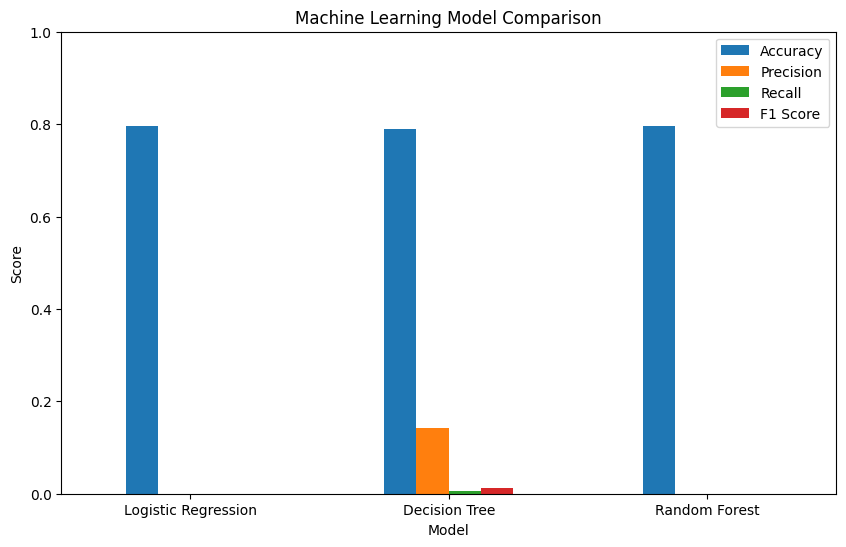

In [55]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

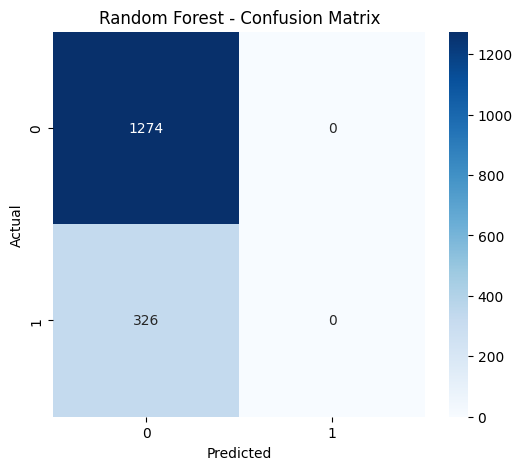

In [56]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [57]:
rf_model = random_forest.named_steps["classifier"]

feature_names = (
    random_forest
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,num__coding_score,0.051719
7,num__technical_score,0.050601
22,num__training_hours,0.050296
6,num__communication_score,0.049877
15,num__coding_platform_score,0.049632
21,num__extracurricular_score,0.049622
19,num__soft_skills_score,0.049562
1,num__cgpa,0.049396
17,num__linkedin_score,0.048709
26,num__overall_skill_score,0.048415


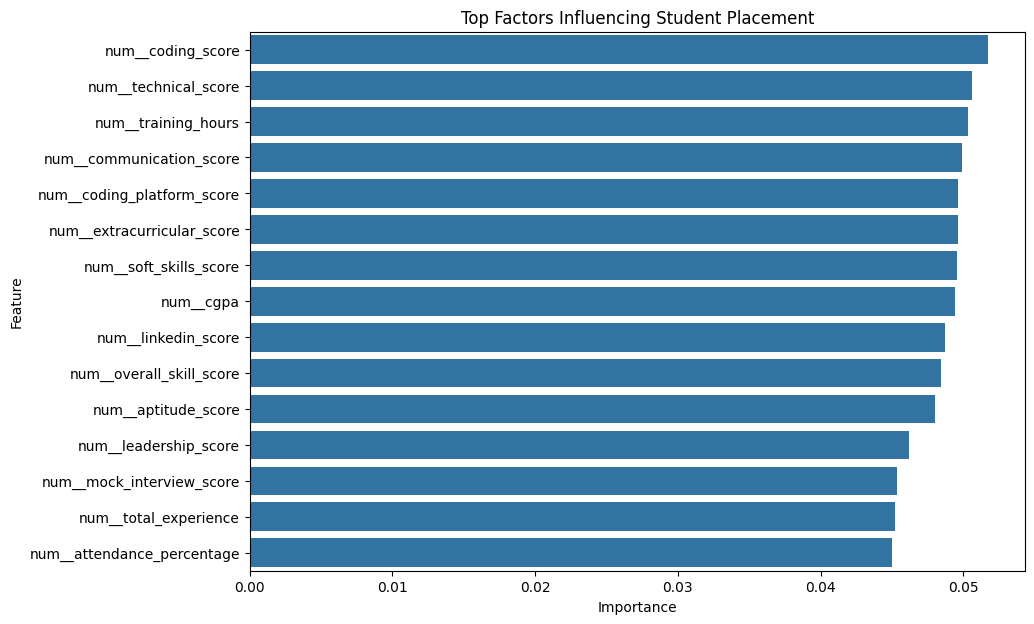

In [58]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Influencing Student Placement")

plt.show()

In [59]:
placement_probability = random_forest.predict_proba(
    X_test
)[:, 1]

probability_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "Placement_Probability": placement_probability
})

probability_df.head(10)

,Actual,Predicted,Placement_Probability
0,0,0,0.201612
1,0,0,0.206800
2,1,0,0.187512
3,0,0,0.206380
4,0,0,0.183920
5,1,0,0.187538
6,0,0,0.149149
7,0,0,0.224405
8,0,0,0.175217
9,0,0,0.191206


In [60]:
def placement_category(probability):

    if probability >= 0.75:
        return "High Probability"

    elif probability >= 0.50:
        return "Medium Probability"

    else:
        return "Low Probability"

In [61]:
probability_df["Category"] = (
    probability_df["Placement_Probability"]
    .apply(placement_category)
)

probability_df.head()

,Actual,Predicted,Placement_Probability,Category
0,0,0,0.201612,Low Probability
1,0,0,0.206800,Low Probability
2,1,0,0.187512,Low Probability
3,0,0,0.206380,Low Probability
4,0,0,0.183920,Low Probability


In [62]:
def generate_recommendations(student):

    recommendations = []

    if student["coding_score"] < 60:
        recommendations.append(
            "Improve coding and problem-solving skills."
        )

    if student["aptitude_score"] < 60:
        recommendations.append(
            "Practice quantitative and logical aptitude."
        )

    if student["communication_score"] < 60:
        recommendations.append(
            "Improve communication and interview skills."
        )

    if student["technical_score"] < 60:
        recommendations.append(
            "Strengthen core technical concepts."
        )

    if student["projects_count"] < 2:
        recommendations.append(
            "Build more practical projects."
        )

    if student["internships_count"] == 0:
        recommendations.append(
            "Try to gain internship experience."
        )

    if student["certifications_count"] == 0:
        recommendations.append(
            "Consider completing relevant certifications."
        )

    if student["mock_interview_score"] < 60:
        recommendations.append(
            "Practice mock interviews."
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Profile looks strong. Continue interview preparation."
        )

    return recommendations

In [63]:
student = df.iloc[0]

recommendations = generate_recommendations(
    student
)

for recommendation in recommendations:
    print("•", recommendation)

• Improve coding and problem-solving skills.
• Practice quantitative and logical aptitude.
• Strengthen core technical concepts.
• Build more practical projects.


In [64]:
def predict_student(student_data):

    student_df = pd.DataFrame(
        [student_data]
    )

    probability = random_forest.predict_proba(
        student_df
    )[0][1]

    prediction = random_forest.predict(
        student_df
    )[0]

    if probability >= 0.75:
        category = "High Placement Probability"

    elif probability >= 0.50:
        category = "Medium Placement Probability"

    else:
        category = "Low Placement Probability"

    return prediction, probability, category

In [65]:
sample_student = X_test.iloc[0].to_dict()

prediction, probability, category = predict_student(
    sample_student
)

print("Placement Prediction:", prediction)
print("Placement Probability:", round(probability * 100, 2), "%")
print("Category:", category)

Placement Prediction: 0
Placement Probability: 20.16 %
Category: Low Placement Probability


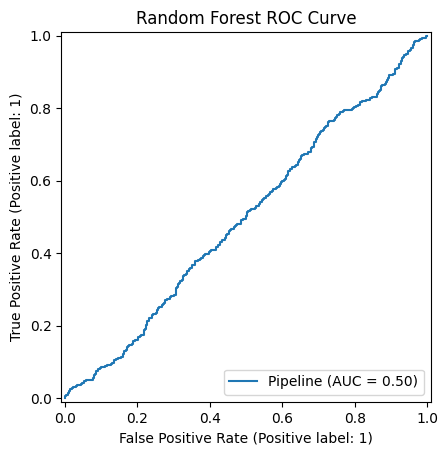

In [66]:
RocCurveDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")

plt.show()

In [67]:
print("===== KEY PROJECT INSIGHTS =====")

print(
    f"Overall Placement Rate: "
    f"{df['placed'].mean() * 100:.2f}%"
)

print(
    f"Average CGPA: "
    f"{df['cgpa'].mean():.2f}"
)

print(
    f"Average Coding Score: "
    f"{df['coding_score'].mean():.2f}"
)

print(
    f"Average Internship Count: "
    f"{df['internships_count'].mean():.2f}"
)

print(
    f"Average Projects: "
    f"{df['projects_count'].mean():.2f}"
)

===== KEY PROJECT INSIGHTS =====
Overall Placement Rate: 20.38%
Average CGPA: 7.58
Average Coding Score: 53.16
Average Internship Count: 0.92
Average Projects: 2.60
